In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(project_root)

c:\Users\mert4325\OneDrive - Nexus365\DPhil\Python\cat-breeding-simulation


# Overview

This notebook simulates one round of a cat-breeding protocol.

The protocol consists of:

1. Preparing two squeezed cat states squeezed along the position basis.
2. Interfering them on a 50:50 beamsplitter.
3. Measuring the momentum quadrature of one output mode using homodyne detection.
4. Sampling a measurement outcome and calculating the corresponding conditional state of the unmeasured mode.
6. Visualising the conditional state using its Wigner function.

The simulation uses a truncated Fock basis and is implemented using QuTiP.

## 1. Preparing the Squeezed Cat State

A coherent state $|\alpha\rangle$ is an eigenstate of the annihilation
operator:

$$
a|\alpha\rangle = \alpha|\alpha\rangle.
$$

In the Fock basis:

$$
|\alpha\rangle
=
e^{-|\alpha|^2/2}
\sum_{n=0}^{\infty}
\frac{\alpha^n}{\sqrt{n!}}|n\rangle.
$$

An even cat state is the coherent superposition:

$$
|\mathrm{cat}_+\rangle
=
\mathcal N_+
\left(
|\alpha\rangle+|-\alpha\rangle
\right),
$$

where $\mathcal N_+$ is the normalisation factor.

The cat state is transformed using the single-mode squeezing operator:

$$
S(\xi)
=
\exp\left[
\frac{1}{2}
\left(
\xi^* a^2-\xi a^{\dagger 2}
\right)
\right].
$$

For real squeezing parameter $r$, squeezing reduces the uncertainty
in one quadrature while increasing the uncertainty in the conjugate
quadrature, preserving the uncertainty relation.

The squeezed cat used as each input to the breeding protocol is:

$$
|\mathrm{SC}\rangle
=
S(r)|\mathrm{cat}_+\rangle.
$$

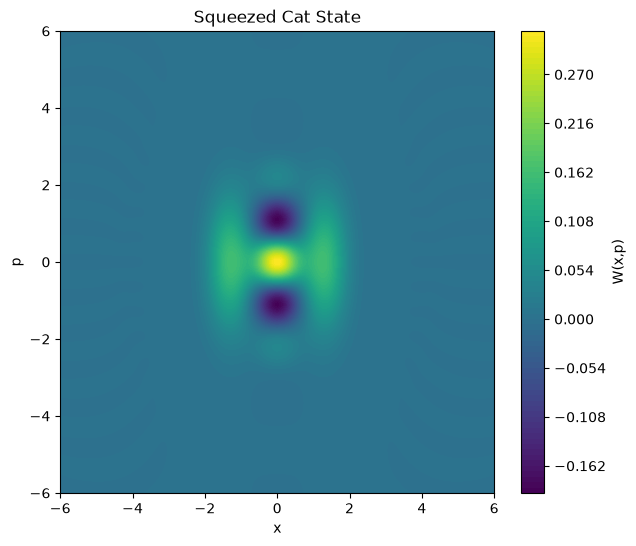

In [5]:
from src.states import make_squeezed_cat
N=40
alpha=1.5
r=0.5
squeezed_cat = make_squeezed_cat(N, alpha, r
)

from src.visualisation import plot_wigner
import numpy as np
x_wigner = np.linspace(-6, 6, 300)
p_wigner = np.linspace(-6, 6, 300)

plot_wigner(
    squeezed_cat,
    x_wigner,
    p_wigner,
    title="Squeezed Cat State"
)

## 2. Beamsplitter

The two input modes are prepared independently in identical
squeezed cat states:

$$
|\Psi_{\mathrm{in}}\rangle
=
|\mathrm{SC}\rangle_A
\otimes
|\mathrm{SC}\rangle_B.
$$

The two modes interfere at a 50:50 beamsplitter. We use the
unitary:

$$
U_{\mathrm{BS}}(\theta)
=
\exp\left[
\theta
\left(
a_A^\dagger a_B-a_Aa_B^\dagger
\right)
\right],
$$

with $\theta=\frac{\pi}{4}$ for a $50:50$ beamsplitter.

The output state is:

$$
|\Psi_{\mathrm{out}}\rangle
=
U_{\mathrm{BS}}|\Psi_{\mathrm{in}}\rangle.
$$

In [8]:
import qutip as qt
psi_in = qt.tensor(squeezed_cat, squeezed_cat)

from src.beamsplitter import apply_beamsplitter

psi_out = apply_beamsplitter(psi_in, N)

#test - remove later
print("Input norm:", psi_in.norm())
print("Output norm:", psi_out.norm())

Input norm: 1.0
Output norm: 0.9999999999999994


## 3. Momentum homodyne measurement

The post-beamsplitter state is represented in the two-mode Fock basis as:

$$
|\Psi_{\mathrm{out}}\rangle
=
\sum_{n,m}
C_{nm}
|n\rangle_A|m\rangle_B.
$$

Here $C_{nm}$ is the probability amplitude associated with finding
$n$ excitations in mode $A$ and $m$ excitations in mode $B$.

Momentum homodyne detection projects the measured mode onto a momentum
quadrature eigenstate $|p\rangle$.

To apply this measurement to a state represented in the Fock basis:

$$
\phi_n(p)
=
\langle p|n\rangle.
$$

These are the momentum-space harmonic-oscillator wavefunctions.

Starting from $\phi_0(p)=\pi^{-1/4}e^{-p^2/2}$ and $\phi_1(p)=-i\sqrt{2}\,p\,\phi_0(p)$, the recurrence relation to generate the higher order wavefunctions is:

$$
\phi_{n+1}(p)
=
-i\sqrt{\frac{2}{n+1}}\,p\,\phi_n(p)
+
\sqrt{\frac{n}{n+1}}\,\phi_{n-1}(p).
$$

We numerically evaluate these functions on a finite momentum grid $p_0,p_1,\ldots,p_{M-1}$ resulting in the array:

$$
\Phi_{in}
=
\langle p_i|n\rangle.
$$

Therefore:

- each **row** corresponds to one possible momentum outcome $p_i$;
- each **column** corresponds to one Fock state $|n\rangle$.

In [14]:
from src.homodyne import momentum_fock_wavefunctions
import numpy as np 

N_test = 40
p_test = np.linspace(-8, 8, 2000)

phi_test = momentum_fock_wavefunctions(
    p_test,
    N_test
)

print(phi_test.shape)

(2000, 40)


The function `conditional_states(psi_out, p_grid)` uses these
wavefunctions to project the measured mode $A$ of the two-mode output
state onto the momentum basis. If

$$
|\Psi_{\mathrm{out}}\rangle
=
\sum_{n,m} C_{nm}|n\rangle_A|m\rangle_B,
$$

then for each momentum value $p_i$,

$$
|\tilde{\psi}_B(p_i)\rangle
=
{}_A\langle p_i|\Psi_{\mathrm{out}}\rangle
$$

is the unnormalised conditional state of the unmeasured mode $B$.
Numerically, its Fock-basis coefficients are calculated using

$$
\tilde c_m(p_i)
=
\sum_n \langle p_i|n\rangle C_{nm},
$$

which is implemented as the matrix multiplication `conditional = phi @ C`.

The function `homodyne_pdf(psi_out, p_grid)` then calculates the
probability density for each homodyne outcome using Born's rule,

$$
P(p_i)
=
\left\|
|\tilde{\psi}_B(p_i)\rangle
\right\|^2
=
\sum_m|\tilde c_m(p_i)|^2.
$$

The resulting numerical distribution is normalised so that:

$$
\int P(p)\,dp = 1.
$$

PDF integral: 1.0000000000000002


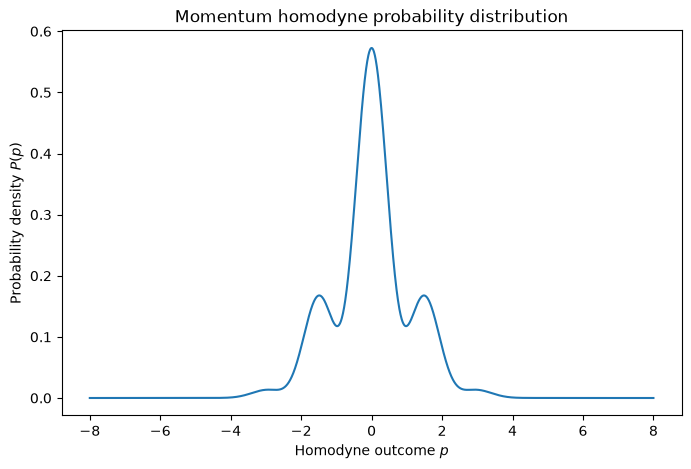

In [15]:
from src.homodyne import homodyne_pdf

pdf_test, conditional_unnorm = homodyne_pdf(
    psi_out,
    p_test
)

print(
    "PDF integral:",
    np.trapezoid(pdf_test, p_test)
)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    p_test,
    pdf_test
)

plt.xlabel("Homodyne outcome $p$")
plt.ylabel("Probability density $P(p)$")
plt.title("Momentum homodyne probability distribution")

plt.show()

## 4. Sampling a homodyne measurement

The probability density $P(p)$ describes the statistics of many
measurements, but a single experimental shot returns one momentum value.

To simulate one shot we use inverse-CDF sampling by first constructing the cumulative distribution function:

$$
F(p)
=
\int_{p_{\min}}^p
P(p')\,dp'.
$$

Then drawing uniform random number: $u\sim U(0,1)$ we find the momentum satisfying:

$$
F(p_{\mathrm{sample}})=u.
$$

Equivalently,

$$
p_{\mathrm{sample}}
=
F^{-1}(u).
$$

In [16]:
from src.homodyne import sample_homodyne

rng = np.random.default_rng(1234)

p_sample = sample_homodyne(
    p_test,
    pdf_test,
    rng=rng
)

print("Sampled homodyne outcome:", p_sample)

Sampled homodyne outcome: 2.173641633621062


`cumulative_trapezoid(pdf, p_grid)` constructs the CDF.

`rng.random()` generates a uniformly distributed number $u$ between
0 and 1.

`np.interp(u, cdf, p_grid)` approximately performs the inverse mapping:

$$
u \longrightarrow p_{\mathrm{sample}}.
$$

Regions containing more probability occupy a larger fraction of the
CDF's interval from 0 to 1, so they are sampled more frequently.

After sampling the homodyne result $p_{\mathrm{sample}}$ we select the
corresponding conditional state of the unmeasured mode.

In the current implementation the homodyne PDF and conditional states are
precomputed on a finite momentum grid. The sampled value will generally
fall between grid points, so we use the nearest grid point to retrieve the
conditional state.

In [17]:
from src.homodyne import conditional_state_from_outcome

conditional_state, p_used = (
    conditional_state_from_outcome(
        conditional_unnorm,
        p_test,
        p_sample
    )
)
print("Measurement outcome:", p_sample)
print("Grid value used:", p_used)
print("Norm:", conditional_state.norm())

Measurement outcome: 2.173641633621062
Grid value used: 2.1730865432716353
Norm: 1.0000000000000002


## 5. Wigner function of the conditional state

The final conditional state is converted back into a QuTiP ket and
visualised using its Wigner function.

The plot below corresponds to the state of the unmeasured mode conditioned
on the particular homodyne outcome sampled in this simulated shot.

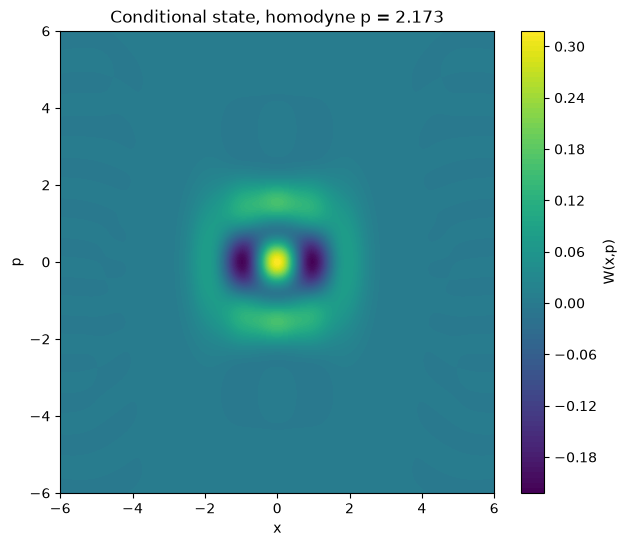

In [18]:
from src.visualisation import plot_wigner

x_wigner = np.linspace(-6, 6, 300)
p_wigner = np.linspace(-6, 6, 300)

plot_wigner(
    conditional_state,
    x_wigner,
    p_wigner,
    title=f"Conditional state, homodyne p = {p_used:.3f}"
)

## Fock-space cutoff convergence

For each candidate cutoff $N$, we obtain a homodyne distribution $P_N(p)$.

Using the largest tested cutoff $N_{\mathrm{ref}}$ as a numerical
reference we compare:

$$
\epsilon_N
=
\max_p
\left|
P_N(p)-P_{N_{\mathrm{ref}}}(p)
\right|.
$$

The cutoff is considered sufficient once increasing $N$ produces a
negligible change in the observable distribution.

This provides a numerical justification for the Hilbert-space dimension
rather than selecting $N$ arbitrarily.

N = 10 | output norm = 1.000000000000 | PDF integral = 1.000000000000
N = 20 | output norm = 1.000000000000 | PDF integral = 1.000000000000
N = 30 | output norm = 1.000000000000 | PDF integral = 1.000000000000
N = 40 | output norm = 1.000000000000 | PDF integral = 1.000000000000
N = 50 | output norm = 1.000000000000 | PDF integral = 1.000000000000


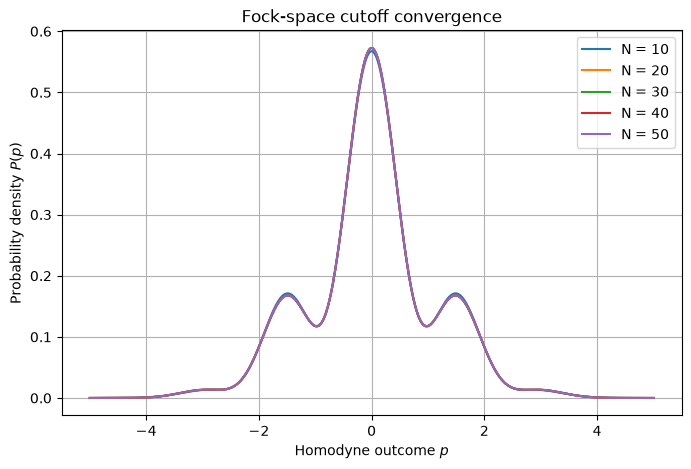


Maximum absolute PDF difference relative to N = 50:
N = 10 : 5.313339e-03
N = 20 : 1.356841e-04
N = 30 : 1.208872e-06
N = 40 : 1.014561e-08


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from src.states import make_squeezed_cat
from src.beamsplitter import apply_beamsplitter
from src.homodyne import homodyne_pdf


# ============================================================
# Parameters
# ============================================================

alpha = 1.5
r = 0.5

# Fock-space cutoffs to test
cutoffs = [10, 20, 30, 40, 50]

# Momentum grid used for the homodyne distribution
p_grid = np.linspace(-5, 5, 1000)


# ============================================================
# Run the complete protocol for each cutoff
# ============================================================

pdfs = {}
states = {}

for N in cutoffs:

    # --------------------------------------------------------
    # 1. Prepare squeezed cat state
    # --------------------------------------------------------
    squeezed_cat = make_squeezed_cat(
        N=N,
        alpha=alpha,
        r=r
    )

    # --------------------------------------------------------
    # 2. Prepare two-mode input state
    # --------------------------------------------------------
    psi_in = qt.tensor(
        squeezed_cat,
        squeezed_cat
    )

    # --------------------------------------------------------
    # 3. Apply 50:50 beamsplitter
    # --------------------------------------------------------
    psi_out = apply_beamsplitter(
        psi_in,
        N=N,
        theta=np.pi / 4
    )

    # --------------------------------------------------------
    # 4. Calculate homodyne PDF
    # --------------------------------------------------------
    pdf, conditional_unnorm = homodyne_pdf(
        psi_out,
        p_grid
    )

    pdfs[N] = pdf
    states[N] = conditional_unnorm

    # --------------------------------------------------------
    # 5. Basic checks
    # --------------------------------------------------------
    pdf_integral = np.trapezoid(
        pdf,
        p_grid
    )

    print(
        f"N = {N:2d} | "
        f"output norm = {psi_out.norm():.12f} | "
        f"PDF integral = {pdf_integral:.12f}"
    )


# ============================================================
# Plot the PDFs for comparison
# ============================================================

plt.figure(figsize=(8, 5))

for N in cutoffs:
    plt.plot(
        p_grid,
        pdfs[N],
        label=f"N = {N}"
    )

plt.xlabel("Homodyne outcome $p$")
plt.ylabel("Probability density $P(p)$")
plt.title("Fock-space cutoff convergence")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# Quantify convergence relative to the largest cutoff
# ============================================================

N_reference = cutoffs[-1]
pdf_reference = pdfs[N_reference]

print("\nMaximum absolute PDF difference relative to "
      f"N = {N_reference}:")

for N in cutoffs[:-1]:

    max_difference = np.max(
        np.abs(
            pdfs[N] - pdf_reference
        )
    )

    print(
        f"N = {N:2d} : "
        f"{max_difference:.6e}"
    )